Dataset created successfully!

First 5 rows:


,Study_Hours,Attendance,Previous_Marks,Final_Marks
0,3.6,78.5,36.7,42.5
1,7.7,45.0,88.7,65.7
2,6.1,49.7,62.8,55.4
3,5.2,93.9,83.7,67.4
4,2.1,76.4,50.8,42.9



Dataset shape:
(200, 4)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Study_Hours     200 non-null    float64
 1   Attendance      200 non-null    float64
 2   Previous_Marks  200 non-null    float64
 3   Final_Marks     200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Statistical summary:


,Study_Hours,Attendance,Previous_Marks,Final_Marks
count,200.000000,200.000000,200.000000,200.000000
mean,4.389000,70.261000,63.844500,55.968500
std,2.065724,17.581728,19.973768,11.648148
min,1.000000,40.300000,30.700000,27.500000
25%,2.600000,55.675000,46.625000,47.475000
50%,4.500000,72.500000,64.150000,54.800000
75%,6.300000,84.500000,82.725000,65.125000
max,7.900000,99.400000,95.000000,82.600000



Missing values:
Study_Hours       0
Attendance        0
Previous_Marks    0
Final_Marks       0
dtype: int64

Duplicate rows:
0

Data cleaning completed!


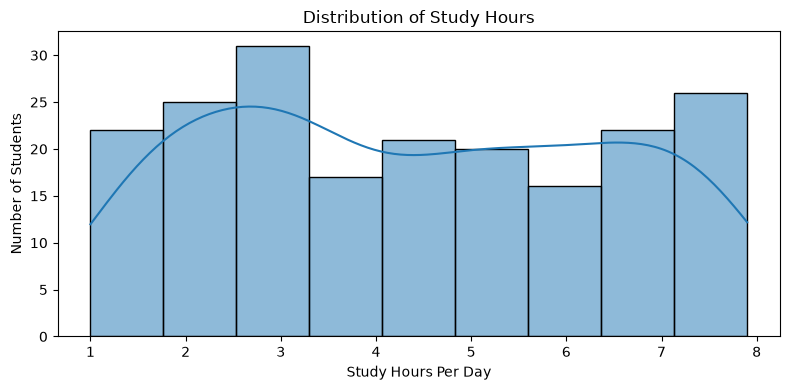

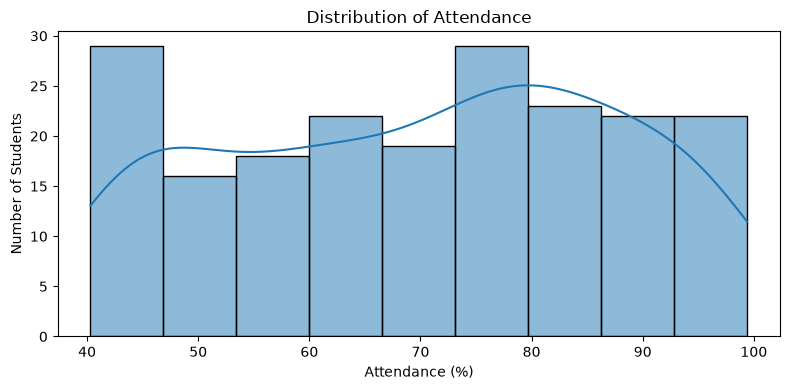

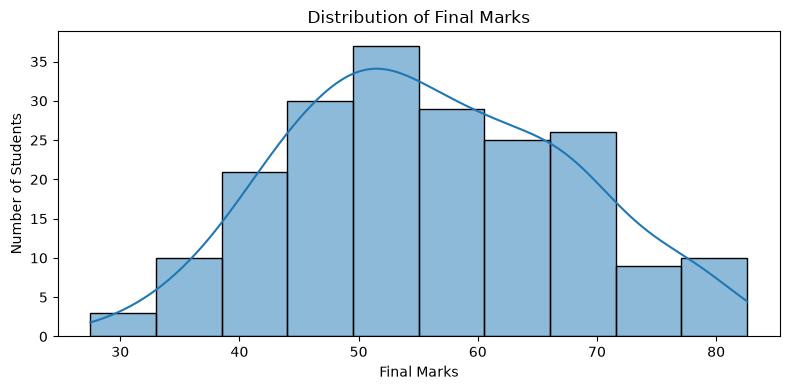

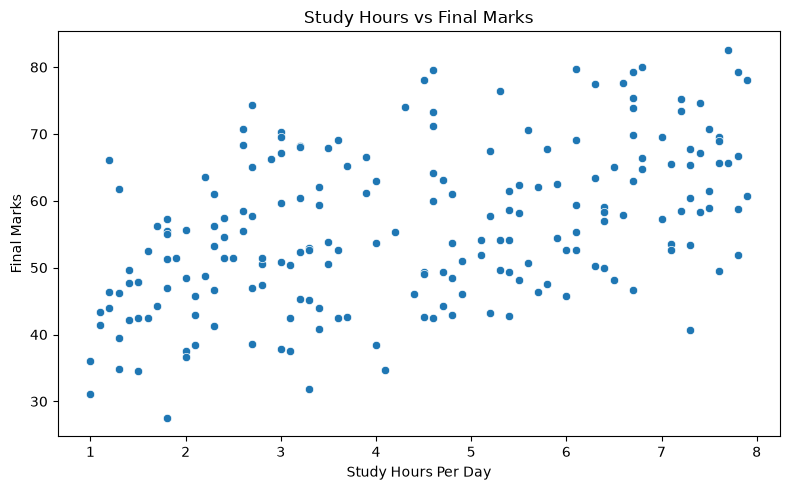

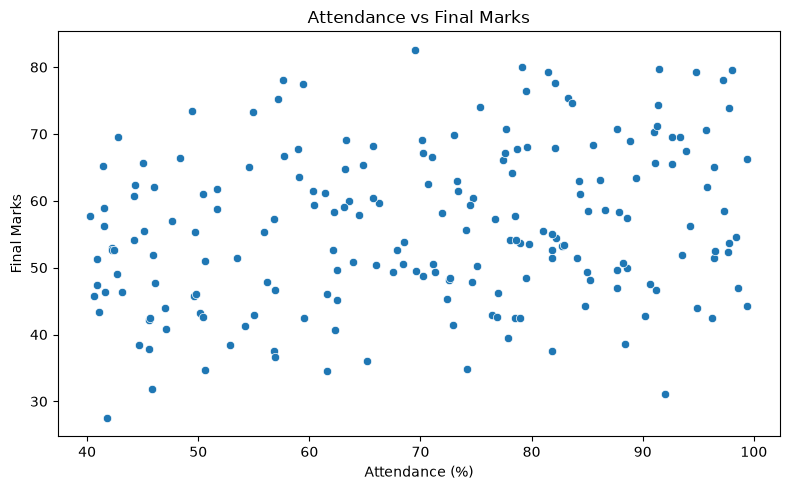

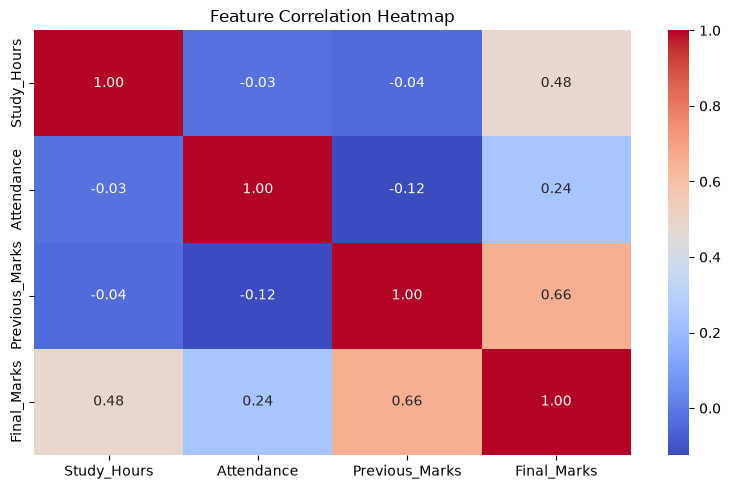


Features:


,Study_Hours,Attendance,Previous_Marks
0,3.6,78.5,36.7
1,7.7,45.0,88.7
2,6.1,49.7,62.8
3,5.2,93.9,83.7
4,2.1,76.4,50.8



Target:


0    42.5
1    65.7
2    55.4
3    67.4
4    42.9
Name: Final_Marks, dtype: float64


Training samples: 160
Testing samples: 40

Model training completed!

Actual vs Predicted Marks:


,Actual_Marks,Predicted_Marks
0,49.4,51.89
1,41.2,44.13
2,49.6,52.17
3,65.1,63.73
4,36.1,32.04
5,52.7,52.75
6,78.0,75.52
7,62.1,53.91
8,62.3,62.67
9,70.6,77.33



========== MODEL EVALUATION ==========
Mean Absolute Error (MAE): 3.5
Mean Squared Error (MSE): 17.21
Root Mean Squared Error (RMSE): 4.15
R2 Score: 0.869


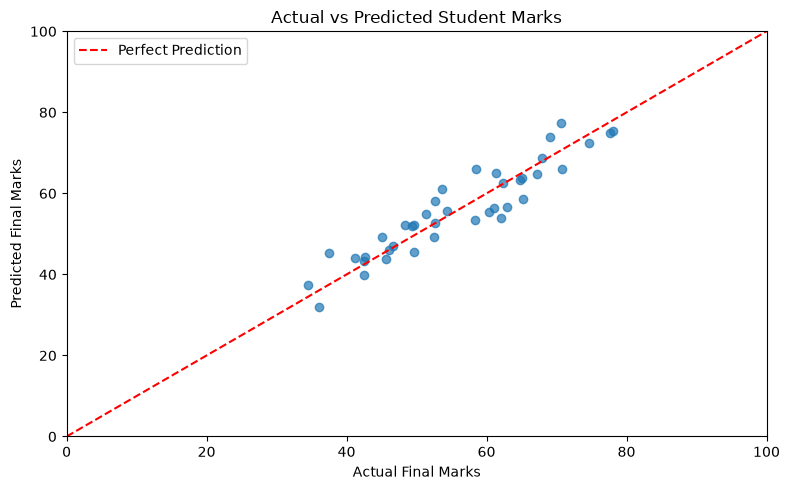


Model Coefficients:


,Feature,Coefficient
0,Study_Hours,2.898103
1,Attendance,0.233811
2,Previous_Marks,0.428815


Intercept: -0.55

========== NEW STUDENT PREDICTION ==========
Study Hours: 5
Attendance: 85 %
Previous Marks: 75
Predicted Final Marks: 65.97

Model saved as student_model.pkl
Prediction using saved model: 65.97

========== PROJECT COMPLETED ==========


In [1]:

# ==========================================================
# EduTrack ML - Student Performance Analyzer
# Complete Beginner-Friendly Machine Learning Project
# ==========================================================

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================================================
# 2. CREATE DEMO DATASET
# ==========================================================

np.random.seed(42)

n = 200

study_hours = np.random.uniform(1, 8, n)
attendance = np.random.uniform(40, 100, n)
previous_marks = np.random.uniform(30, 95, n)

# Synthetic marks formula for practice only
noise = np.random.normal(0, 5, n)

final_marks = (
    3 * study_hours
    + 0.25 * attendance
    + 0.4 * previous_marks
    + noise
)

final_marks = np.clip(final_marks, 0, 100)

df = pd.DataFrame({
    "Study_Hours": study_hours.round(1),
    "Attendance": attendance.round(1),
    "Previous_Marks": previous_marks.round(1),
    "Final_Marks": final_marks.round(1)
})

# Save dataset as CSV
df.to_csv("student_performance.csv", index=False)

print("Dataset created successfully!")

# ==========================================================
# 3. LOAD AND EXPLORE DATA
# ==========================================================

df = pd.read_csv("student_performance.csv")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
display(df.describe())

# ==========================================================
# 4. DATA CLEANING
# ==========================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

# Remove duplicate rows if any
df = df.drop_duplicates().copy()

# Fill missing numerical values with column median
df = df.fillna(df.median(numeric_only=True))

print("\nData cleaning completed!")

# ==========================================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

# Study hours distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Study_Hours", kde=True)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Attendance distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Attendance", kde=True)
plt.title("Distribution of Attendance")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Final marks distribution
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Final_Marks", kde=True)
plt.title("Distribution of Final Marks")
plt.xlabel("Final Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

# Study hours vs final marks
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Marks"
)
plt.title("Study Hours vs Final Marks")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Final Marks")
plt.tight_layout()
plt.show()

# Attendance vs final marks
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Attendance",
    y="Final_Marks"
)
plt.title("Attendance vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# ==========================================================
# 6. FEATURES AND TARGET
# ==========================================================

X = df[[
    "Study_Hours",
    "Attendance",
    "Previous_Marks"
]]

y = df["Final_Marks"]

print("\nFeatures:")
display(X.head())

print("\nTarget:")
display(y.head())

# ==========================================================
# 7. TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ==========================================================
# 8. TRAIN LINEAR REGRESSION MODEL
# ==========================================================

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel training completed!")

# ==========================================================
# 9. MAKE PREDICTIONS
# ==========================================================

y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual_Marks": y_test.values,
    "Predicted_Marks": y_pred.round(2)
})

print("\nActual vs Predicted Marks:")
display(results.head(10))

# ==========================================================
# 10. MODEL EVALUATION
# ==========================================================

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n========== MODEL EVALUATION ==========")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 3))

# ==========================================================
# 11. ACTUAL VS PREDICTED GRAPH
# ==========================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [0, 100],
    [0, 100],
    "r--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Final Marks")
plt.ylabel("Predicted Final Marks")
plt.title("Actual vs Predicted Student Marks")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# 12. MODEL COEFFICIENTS
# ==========================================================

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
display(coefficients)

print("Intercept:", round(model.intercept_, 2))

# ==========================================================
# 13. PREDICT MARKS FOR A NEW STUDENT
# ==========================================================

new_student = pd.DataFrame({
    "Study_Hours": [5],
    "Attendance": [85],
    "Previous_Marks": [75]
})

predicted_marks = model.predict(new_student)[0]

print("\n========== NEW STUDENT PREDICTION ==========")
print("Study Hours:", new_student["Study_Hours"].iloc[0])
print("Attendance:", new_student["Attendance"].iloc[0], "%")
print("Previous Marks:", new_student["Previous_Marks"].iloc[0])
print("Predicted Final Marks:", round(predicted_marks, 2))

# ==========================================================
# 14. SAVE TRAINED MODEL
# ==========================================================

joblib.dump(model, "student_model.pkl")

print("\nModel saved as student_model.pkl")

# ==========================================================
# 15. LOAD SAVED MODEL AND TEST
# ==========================================================

loaded_model = joblib.load("student_model.pkl")

loaded_prediction = loaded_model.predict(new_student)

print(
    "Prediction using saved model:",
    round(loaded_prediction[0], 2)
)

print("\n========== PROJECT COMPLETED ==========")